In [29]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

sigma = 0.564  # ≈ pi/6 (noise strength)
N_list = np.linspace(20, 400, 10, dtype=int)

BATCH_SIZE    = 4
LR_DEFAULT    = 1e-3
N_EPOCHS_FC   = 400
N_EPOCHS_CNN  = 400
OUTPUT_DIM    = 16


In [2]:
def proj(ket: np.ndarray) -> np.ndarray:
    return ket @ ket.conj().T

def build_projector_matrix() -> np.ndarray:
    """Build the 6x6 matrix P of two-qubit projectors as in Lohani."""
    H = np.array([[1.0], [0.0]], dtype=complex)
    V = np.array([[0.0], [1.0]], dtype=complex)

    D = (H + V) / np.sqrt(2)
    A = (H - V) / np.sqrt(2)
    R = (H + 1j * V) / np.sqrt(2)
    L = (H - 1j * V) / np.sqrt(2)

    h = proj(H)
    v = proj(V)
    d = proj(D)
    a = proj(A)
    r = proj(R)
    l = proj(L)

    projs = [h, v, d, a, r, l]
    P = np.empty((6, 6), dtype=object)
    for i in range(6):
        for j in range(6):
            P[i, j] = np.kron(projs[i], projs[j])
    return P

P = build_projector_matrix()


In [3]:
def random_mixed_state() -> np.ndarray:
    """Generate a random 4x4 mixed state using the Ginibre ensemble."""
    G = (np.random.normal(size=(4, 4))
         + 1j * np.random.normal(size=(4, 4)))
    rho = G @ G.conj().T
    rho /= np.trace(rho)
    return rho


In [4]:
def noisy_unitary(sigma: float) -> np.ndarray:
    """Random SU(2) unitary from Gaussian-distributed Euler angles."""
    theta, phi, zeta = np.random.normal(0, sigma, 3)
    U = np.array([
        [np.exp(1j * phi / 2) * np.cos(theta),      -1j * np.exp(1j * zeta) * np.sin(theta)],
        [-1j * np.exp(-1j * zeta) * np.sin(theta),   np.exp(-1j * phi / 2) * np.cos(theta)]
    ], dtype=complex)
    return U

def rotate_projector(P_ij: np.ndarray, sigma: float) -> np.ndarray:
    """Rotate a two-qubit projector by independent random unitaries on each qubit."""
    U1 = noisy_unitary(sigma)
    U2 = noisy_unitary(sigma)
    U  = np.kron(U1, U2)
    return U @ P_ij @ U.conj().T


In [5]:
def measure_state(rho: np.ndarray, P: np.ndarray, sigma: float) -> np.ndarray:
    """
    Return 6x6 matrix of noisy measurement probabilities M_ij = Tr(rho P_ij^noisy).
    """
    M = np.empty((6, 6), dtype=float)
    for i in range(6):
        for j in range(6):
            P_noisy = rotate_projector(P[i, j], sigma)
            M[i, j] = np.real(np.trace(rho @ P_noisy))
    return M


In [6]:
def generate_dataset(N: int, P: np.ndarray, sigma: float):
    """
    Generate N samples:
      X: (N, 36) flattened measurement probabilities
      Y: (N, 32) concat(Re(vec(rho)), Im(vec(rho)))
    """
    X = np.zeros((N, 36), dtype=np.float32)
    Y = np.zeros((N, 32), dtype=np.float32)

    for k in range(N):
        rho = random_mixed_state()
        M   = measure_state(rho, P, sigma)
 
        X[k] = M.reshape(-1)

        rho_flat = rho.reshape(-1)
        Y[k, :16] = np.real(rho_flat)
        Y[k, 16:] = np.imag(rho_flat)

    return X, Y



In [7]:
def fidelity_from_vecs(pred_flat: np.ndarray, true_flat: np.ndarray) -> float:
    """
    Both pred_flat and true_flat: length-32 real arrays (Re||Im of vec(rho)).
    Returns Uhlmann fidelity F in [0,1].
    """
    pred_rho = pred_flat[:16] + 1j * pred_flat[16:]
    true_rho = true_flat[:16] + 1j * true_flat[16:]

    pred_rho = pred_rho.reshape(4, 4)
    true_rho = true_rho.reshape(4, 4)

    pred_rho = (pred_rho + pred_rho.conj().T) / 2
    true_rho = (true_rho + true_rho.conj().T) / 2
    pred_rho /= np.trace(pred_rho)
    true_rho /= np.trace(true_rho)

    sqrt_true = sqrtm(true_rho)
    inner     = sqrt_true @ pred_rho @ sqrt_true
    F         = np.real(np.trace(sqrtm(inner)) ** 2)
    return float(np.clip(F, 0.0, 1.0))


In [8]:
def tau_from_params_np(params: np.ndarray) -> np.ndarray:
    """
    params: shape (16,) real
    Returns a 4x4 complex lower-triangular tau.
    
    Layout:
      diag:       t00, t11, t22, t33  (real)
      off-diag:   6 complex entries (Re, Im) each:
        t10, t20, t21, t30, t31, t32
    """
    p = params
    assert p.shape[-1] == 16

    t00 = p[0]
    t11 = p[3]
    t22 = p[8]
    t33 = p[15]

    t10 = p[1]  + 1j * p[2]
    t20 = p[4]  + 1j * p[5]
    t21 = p[6]  + 1j * p[7]
    t30 = p[9]  + 1j * p[10]
    t31 = p[11] + 1j * p[12]
    t32 = p[13] + 1j * p[14]

    tau = np.zeros((4, 4), dtype=complex)
    tau[0, 0] = t00

    tau[1, 0] = t10
    tau[1, 1] = t11

    tau[2, 0] = t20
    tau[2, 1] = t21
    tau[2, 2] = t22

    tau[3, 0] = t30
    tau[3, 1] = t31
    tau[3, 2] = t32
    tau[3, 3] = t33

    return tau

def rho_from_tau_np(params: np.ndarray) -> np.ndarray:
    """
    params: shape (16,)
    Return 4x4 density matrix rho = tau^† tau / Tr(tau^† tau).
    """
    tau = tau_from_params_np(params)
    rho = tau.conj().T @ tau
    rho = (rho + rho.conj().T) / 2  # numerical Hermiticity
    rho /= np.trace(rho)
    return rho


In [9]:
def fidelity_from_tau_params(pred_params: np.ndarray,
                             true_flat: np.ndarray) -> float:
    """
    pred_params: length-16 real array (tau params)
    true_flat:   length-32 real array (Re||Im vec(rho_true))
    """
    rho_pred = rho_from_tau_np(pred_params)

    true_rho = true_flat[:16] + 1j * true_flat[16:]
    true_rho = true_rho.reshape(4, 4)
    true_rho = (true_rho + true_rho.conj().T) / 2
    true_rho /= np.trace(true_rho)

    sqrt_true = sqrtm(true_rho)
    inner     = sqrt_true @ rho_pred @ sqrt_true
    F         = np.real(np.trace(sqrtm(inner)) ** 2)
    return float(np.clip(F, 0.0, 1.0))


In [10]:
def build_stokes_matrix(P: np.ndarray) -> np.ndarray:
    """
    Build A such that M_flat ≈ A @ vec(rho).
    Each row is vec(P_k^T).
    """
    A = np.zeros((36, 16), dtype=complex)
    idx = 0
    for i in range(6):
        for j in range(6):
            A[idx, :] = P[i, j].T.reshape(-1)
            idx += 1
    return A

A_stokes = build_stokes_matrix(P)

def stokes_reconstruct(M_flat: np.ndarray, A: np.ndarray = A_stokes) -> np.ndarray:
    """
    Linear inversion (least squares) to reconstruct rho from M_flat.
    Returns a 4x4 density matrix.
    """
    x, *_ = np.linalg.lstsq(A, M_flat.astype(complex), rcond=None)
    rho_est = x.reshape(4, 4)

    rho_est = (rho_est + rho_est.conj().T) / 2
    rho_est /= np.trace(rho_est)
    return rho_est


In [11]:
def precompute_stokes_fidelities(X_test: np.ndarray,
                                 Y_test: np.ndarray):
    """
    For each test example:
      - reconstruct rho_stokes from M = X_test[k]
      - compute fidelity vs true rho from Y_test[k]
    Returns:
      avg_fid_stokes: float
      stokes_flats: (N_test, 32) array of Re/Im vec(rho_stokes)
    """
    stokes_flats = []
    stokes_fids  = []

    for k in range(len(X_test)):
        rho_stokes = stokes_reconstruct(X_test[k])

        rho_stokes_flat = rho_stokes.reshape(-1)
        rho_stokes_flat = np.concatenate(
            [np.real(rho_stokes_flat), np.imag(rho_stokes_flat)]
        ).astype(np.float32)
        stokes_flats.append(rho_stokes_flat)

        f = fidelity_from_vecs(rho_stokes_flat, Y_test[k])
        stokes_fids.append(f)

    stokes_flats = np.stack(stokes_flats, axis=0)
    avg_fid_stokes = float(np.mean(stokes_fids))

    return avg_fid_stokes, stokes_flats


In [12]:
# %% Tau parameterisation and losses (Torch)

def tau_from_params_torch(params: torch.Tensor) -> torch.Tensor:
    """
    params: (batch, 16) real
    Returns tau: (batch, 4, 4) complex lower-triangular.

    Layout matches the NumPy version:
      diag:       t00, t11, t22, t33  (real)
      off-diag:   6 complex entries (Re, Im):
        t10, t20, t21, t30, t31, t32
    """
    assert params.shape[-1] == 16
    p = params

    t00 = p[:, 0]
    t11 = p[:, 3]
    t22 = p[:, 8]
    t33 = p[:, 15]

    t10 = p[:, 1]  + 1j * p[:, 2]
    t20 = p[:, 4]  + 1j * p[:, 5]
    t21 = p[:, 6]  + 1j * p[:, 7]
    t30 = p[:, 9]  + 1j * p[:, 10]
    t31 = p[:, 11] + 1j * p[:, 12]
    t32 = p[:, 13] + 1j * p[:, 14]

    batch = p.shape[0]
    tau = torch.zeros((batch, 4, 4), dtype=torch.cfloat, device=p.device)

    tau[:, 0, 0] = t00

    tau[:, 1, 0] = t10
    tau[:, 1, 1] = t11

    tau[:, 2, 0] = t20
    tau[:, 2, 1] = t21
    tau[:, 2, 2] = t22

    tau[:, 3, 0] = t30
    tau[:, 3, 1] = t31
    tau[:, 3, 2] = t32
    tau[:, 3, 3] = t33

    return tau


def rho_from_tau_torch(params: torch.Tensor) -> torch.Tensor:
    """
    params: (batch, 16) real
    returns rho: (batch, 4, 4) complex
    """
    tau = tau_from_params_torch(params)
    rho = torch.matmul(tau.conj().transpose(-2, -1), tau)
    rho = 0.5 * (rho + rho.conj().transpose(-2, -1))
    tr  = torch.real(torch.diagonal(rho, dim1=-2, dim2=-1).sum(-1, keepdim=True))
    rho = rho / (tr.unsqueeze(-1) + 1e-8)
    return rho


def rho_true_from_vec_torch(target: torch.Tensor) -> torch.Tensor:
    """
    target: (batch, 32) real = Re||Im vec(rho_true)
    returns rho_true: (batch, 4, 4) complex
    """
    re = target[:, :16]
    im = target[:, 16:]
    rho = torch.complex(re, im).reshape(-1, 4, 4)
    rho = 0.5 * (rho + rho.conj().transpose(-2, -1))
    tr  = torch.real(torch.diagonal(rho, dim1=-2, dim2=-1).sum(-1, keepdim=True))
    rho = rho / (tr.unsqueeze(-1) + 1e-8)
    return rho


def fidelity_loss_tau(pred_params: torch.Tensor,
                      target_vec: torch.Tensor) -> torch.Tensor:
    """
    1 - mean fidelity between rho(pred_params) and rho_true.
    pred_params: (batch, 16)
    target_vec:  (batch, 32)
    """
    rho_p = rho_from_tau_torch(pred_params)
    rho_t = rho_true_from_vec_torch(target_vec)

    evals_t, vecs_t = torch.linalg.eigh(rho_t)
    diag_sqrt = torch.diag_embed(torch.sqrt(torch.clamp(evals_t, min=0))).to(torch.cfloat)
    sqrt_t    = vecs_t @ diag_sqrt @ vecs_t.conj().transpose(-2, -1)

    inner = sqrt_t @ rho_p @ sqrt_t
    evals_inner, _ = torch.linalg.eigh(inner)
    F = (torch.sqrt(torch.clamp(evals_inner, min=0)).sum(dim=-1)) ** 2

    return 1.0 - F.mean()


def mse_rho_loss_tau(pred_params: torch.Tensor,
                     target_vec: torch.Tensor) -> torch.Tensor:
    """
    MSE between rho(pred_params) and rho_true at the matrix level.
    """
    rho_p = rho_from_tau_torch(pred_params)
    rho_t = rho_true_from_vec_torch(target_vec)

    diff = rho_p - rho_t
    # Mean squared magnitude over all entries and batch
    return (diff.real**2 + diff.imag**2).mean()


In [13]:
def get_loss_fn(loss_type: str):
    if loss_type == "mse":
        # MSE on density matrices
        return mse_rho_loss_tau
    elif loss_type == "fidelity":
        return fidelity_loss_tau
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")

In [14]:
def make_fc_model(output_dim: int = OUTPUT_DIM) -> nn.Module:
    """
    Fully-connected network:
      36 -> 720 -> 450 -> 32
    """
    model = nn.Sequential(
        nn.Linear(36, 720),
        nn.ReLU(),
        nn.Linear(720, 450),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(450, output_dim)
    )
    return model

def make_cnn_model(output_dim: int = OUTPUT_DIM) -> nn.Module:
    """
    CNN operating on the 6x6 measurement grid.
    """
    model = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),  # 6x6 -> 3x3

        nn.Flatten(),                           # 32 * 3 * 3 = 288
        nn.Linear(32 * 3 * 3, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, output_dim)
    )
    return model


In [15]:
def train_model(model: nn.Module,
                X_train: torch.Tensor,
                Y_train: torch.Tensor,
                loss_type: str,
                n_epochs: int,
                lr: float,
                is_cnn: bool = False) -> nn.Module:

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn   = get_loss_fn(loss_type)

    for epoch in range(n_epochs):
        model.train()
        for i in range(0, len(X_train), BATCH_SIZE):
            X_batch = X_train[i:i + BATCH_SIZE]
            Y_batch = Y_train[i:i + BATCH_SIZE]

            if is_cnn:
                X_batch = X_batch.view(-1, 1, 6, 6)  # (batch, 1, 6, 6)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = loss_fn(pred, Y_batch)
            loss.backward()
            optimizer.step()

    return model


In [16]:
def evaluate_model_fidelity(model: nn.Module,
                            X_test_t: torch.Tensor,
                            Y_test: np.ndarray,
                            is_cnn: bool = False) -> float:
    """
    Run the model on the test set and return mean fidelity vs true rho (from Y_test).
    """
    model.eval()
    with torch.no_grad():
        if is_cnn:
            X_in = X_test_t.view(-1, 1, 6, 6)
        else:
            X_in = X_test_t
        pred = model(X_in).numpy()  # (N_test, OUTPUT_DIM)

    fids = [
        fidelity_from_tau_params(pred[k], Y_test[k])
        for k in range(len(pred))
    ]
    return float(np.mean(fids))


In [ ]:
avg_fids_fc_mse     = []
avg_fids_fc_fid     = []
avg_fids_cnn_mse    = []
avg_fids_cnn_fid    = []
avg_fids_stokes_all = []
times_stokes = []
times_NN = []
times_CNN = []

for N in N_list:
    print(f"\n=== Experiments for N = {N} ===")

    np.random.seed(seed)
    torch.manual_seed(seed)

    X, Y = generate_dataset(N, P, sigma)

    split = int(0.8 * N)
    X_train, X_test = X[:split], X[split:]
    Y_train, Y_test = Y[:split], Y[split:]

    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    Y_train_t = torch.from_numpy(Y_train.astype(np.float32))
    X_test_t  = torch.from_numpy(X_test.astype(np.float32))

    avg_fid_stokes, stokes_flats = precompute_stokes_fidelities(X_test, Y_test)
    avg_fids_stokes_all.append(avg_fid_stokes)
    print(f"    Stokes Avg fidelity:           {avg_fid_stokes:.6e}")

    fc_mse_model = make_fc_model()
    fc_mse_model = train_model(fc_mse_model,
                               X_train_t, Y_train_t,
                               loss_type="mse",
                               n_epochs=N_EPOCHS_FC,
                               lr=LR_DEFAULT,
                               is_cnn=False)
    fc_mse_fid = evaluate_model_fidelity(fc_mse_model, X_test_t, Y_test, is_cnn=False)
    avg_fids_fc_mse.append(fc_mse_fid)
    print(f"    FC (MSE) Avg fidelity:         {fc_mse_fid:.6e}")

    fc_fid_model = make_fc_model()
    fc_fid_model = train_model(fc_fid_model,
                               X_train_t, Y_train_t,
                               loss_type="fidelity",
                               n_epochs=N_EPOCHS_FC,
                               lr=LR_DEFAULT,
                               is_cnn=False)
    fc_fid_fid = evaluate_model_fidelity(fc_fid_model, X_test_t, Y_test, is_cnn=False)
    avg_fids_fc_fid.append(fc_fid_fid)
    print(f"    FC (Fidelity loss) Avg fidelity: {fc_fid_fid:.6e}")

    cnn_mse_model = make_cnn_model()
    cnn_mse_model = train_model(cnn_mse_model,
                                X_train_t, Y_train_t,
                                loss_type="mse",
                                n_epochs=N_EPOCHS_CNN,
                                lr=LR_DEFAULT,
                                is_cnn=True)
    cnn_mse_fid = evaluate_model_fidelity(cnn_mse_model, X_test_t, Y_test, is_cnn=True)
    avg_fids_cnn_mse.append(cnn_mse_fid)
    print(f"    CNN (MSE) Avg fidelity:        {cnn_mse_fid:.6e}")

    cnn_fid_model = make_cnn_model()
    cnn_fid_model = train_model(cnn_fid_model,
                                X_train_t, Y_train_t,
                                loss_type="fidelity",
                                n_epochs=N_EPOCHS_CNN,
                                lr=LR_DEFAULT,
                                is_cnn=True)
    cnn_fid_fid = evaluate_model_fidelity(cnn_fid_model, X_test_t, Y_test, is_cnn=True)
    avg_fids_cnn_fid.append(cnn_fid_fid)
    print(f"    CNN (Fidelity loss) Avg fidelity: {cnn_fid_fid:.6e}")



=== Experiments for N = 20 ===
    Stokes Avg fidelity:           7.770460e-01
    FC (MSE) Avg fidelity:         6.992200e-01
    FC (Fidelity loss) Avg fidelity: 7.301897e-01
    CNN (MSE) Avg fidelity:        7.360153e-01
    CNN (Fidelity loss) Avg fidelity: 7.043180e-01

=== Experiments for N = 40 ===
    Stokes Avg fidelity:           8.364170e-01
    FC (MSE) Avg fidelity:         7.680557e-01
    FC (Fidelity loss) Avg fidelity: 7.544228e-01
    CNN (MSE) Avg fidelity:        7.546526e-01
    CNN (Fidelity loss) Avg fidelity: 7.573082e-01

=== Experiments for N = 60 ===
    Stokes Avg fidelity:           8.388879e-01
    FC (MSE) Avg fidelity:         7.545912e-01
    FC (Fidelity loss) Avg fidelity: 7.757554e-01
    CNN (MSE) Avg fidelity:        7.261178e-01
    CNN (Fidelity loss) Avg fidelity: 7.244650e-01

=== Experiments for N = 80 ===
    Stokes Avg fidelity:           8.330264e-01
    FC (MSE) Avg fidelity:         7.042517e-01
    FC (Fidelity loss) Avg fidelity: 7.61

In [30]:
import time

avg_fids_fc_mse     = []
avg_fids_fc_fid     = []
avg_fids_cnn_mse    = []
avg_fids_cnn_fid    = []
avg_fids_stokes_all = []

times_stokes = []
times_fc_mse_test  = []
times_fc_fid_test  = []
times_cnn_mse_test = []
times_cnn_fid_test = []


for N in N_list:
    print(f"\n=== Experiments for N = {N} ===")

    np.random.seed(seed)
    torch.manual_seed(seed)

    X, Y = generate_dataset(N, P, sigma)

    split = int(0.8 * N)
    X_train, X_test = X[:split], X[split:]
    Y_train, Y_test = Y[:split], Y[split:]

    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    Y_train_t = torch.from_numpy(Y_train.astype(np.float32))
    X_test_t  = torch.from_numpy(X_test.astype(np.float32))

    # ---- Stokes timing (test set only)
    t0 = time.perf_counter()
    avg_fid_stokes, stokes_flats = precompute_stokes_fidelities(X_test, Y_test)
    t1 = time.perf_counter()
    times_stokes.append(t1 - t0)

    avg_fids_stokes_all.append(avg_fid_stokes)
    print(f"    Stokes Avg fidelity: {avg_fid_stokes:.6e} | time={times_stokes[-1]:.4f}s")

    # ---- FC (MSE): train (NOT timed)
    fc_mse_model = make_fc_model()
    fc_mse_model = train_model(
        fc_mse_model, X_train_t, Y_train_t,
        loss_type="mse",
        n_epochs=N_EPOCHS_FC,
        lr=LR_DEFAULT,
        is_cnn=False
    )

    # FC (MSE): inference/test timing only
    fc_mse_model.eval()
    t0 = time.perf_counter()
    with torch.no_grad():
        fc_mse_fid = evaluate_model_fidelity(fc_mse_model, X_test_t, Y_test, is_cnn=False)
    t1 = time.perf_counter()
    times_fc_mse_test.append(t1 - t0)

    avg_fids_fc_mse.append(fc_mse_fid)
    print(f"    FC (MSE) Avg fidelity: {fc_mse_fid:.6e} | test time={times_fc_mse_test[-1]:.4f}s")

    # ---- FC (Fidelity): train (NOT timed)
    fc_fid_model = make_fc_model()
    fc_fid_model = train_model(
        fc_fid_model, X_train_t, Y_train_t,
        loss_type="fidelity",
        n_epochs=N_EPOCHS_FC,
        lr=LR_DEFAULT,
        is_cnn=False
    )

    # FC (Fidelity): inference/test timing only
    fc_fid_model.eval()
    t0 = time.perf_counter()
    with torch.no_grad():
        fc_fid_fid = evaluate_model_fidelity(fc_fid_model, X_test_t, Y_test, is_cnn=False)
    t1 = time.perf_counter()
    times_fc_fid_test.append(t1 - t0)

    avg_fids_fc_fid.append(fc_fid_fid)
    print(f"    FC (Fidelity loss) Avg fidelity: {fc_fid_fid:.6e} | test time={times_fc_fid_test[-1]:.4f}s")

    # ---- CNN (MSE): train (NOT timed)
    cnn_mse_model = make_cnn_model()
    cnn_mse_model = train_model(
        cnn_mse_model, X_train_t, Y_train_t,
        loss_type="mse",
        n_epochs=N_EPOCHS_CNN,
        lr=LR_DEFAULT,
        is_cnn=True
    )

    # CNN (MSE): inference/test timing only
    cnn_mse_model.eval()
    t0 = time.perf_counter()
    with torch.no_grad():
        cnn_mse_fid = evaluate_model_fidelity(cnn_mse_model, X_test_t, Y_test, is_cnn=True)
    t1 = time.perf_counter()
    times_cnn_mse_test.append(t1 - t0)

    avg_fids_cnn_mse.append(cnn_mse_fid)
    print(f"    CNN (MSE) Avg fidelity: {cnn_mse_fid:.6e} | test time={times_cnn_mse_test[-1]:.4f}s")

    # ---- CNN (Fidelity): train (NOT timed)
    cnn_fid_model = make_cnn_model()
    cnn_fid_model = train_model(
        cnn_fid_model, X_train_t, Y_train_t,
        loss_type="fidelity",
        n_epochs=N_EPOCHS_CNN,
        lr=LR_DEFAULT,
        is_cnn=True
    )

    # CNN (Fidelity): inference/test timing only
    cnn_fid_model.eval()
    t0 = time.perf_counter()
    with torch.no_grad():
        cnn_fid_fid = evaluate_model_fidelity(cnn_fid_model, X_test_t, Y_test, is_cnn=True)
    t1 = time.perf_counter()
    times_cnn_fid_test.append(t1 - t0)

    avg_fids_cnn_fid.append(cnn_fid_fid)
    print(f"    CNN (Fidelity loss) Avg fidelity: {cnn_fid_fid:.6e} | test time={times_cnn_fid_test[-1]:.4f}s")



=== Experiments for N = 20 ===
    Stokes Avg fidelity: 7.770460e-01 | time=0.0098s
    FC (MSE) Avg fidelity: 6.992200e-01 | test time=0.0020s
    FC (Fidelity loss) Avg fidelity: 7.301897e-01 | test time=0.0004s
    CNN (MSE) Avg fidelity: 7.360153e-01 | test time=0.0014s
    CNN (Fidelity loss) Avg fidelity: 7.043180e-01 | test time=0.0005s

=== Experiments for N = 62 ===
    Stokes Avg fidelity: 8.425328e-01 | time=0.0010s
    FC (MSE) Avg fidelity: 7.279336e-01 | test time=0.0014s
    FC (Fidelity loss) Avg fidelity: 7.683418e-01 | test time=0.0017s
    CNN (MSE) Avg fidelity: 7.101036e-01 | test time=0.0009s
    CNN (Fidelity loss) Avg fidelity: 6.916105e-01 | test time=0.0014s

=== Experiments for N = 104 ===
    Stokes Avg fidelity: 8.540226e-01 | time=0.0017s
    FC (MSE) Avg fidelity: 7.643086e-01 | test time=0.0020s
    FC (Fidelity loss) Avg fidelity: 7.919050e-01 | test time=0.0026s
    CNN (MSE) Avg fidelity: 7.687829e-01 | test time=0.0049s
    CNN (Fidelity loss) Avg f

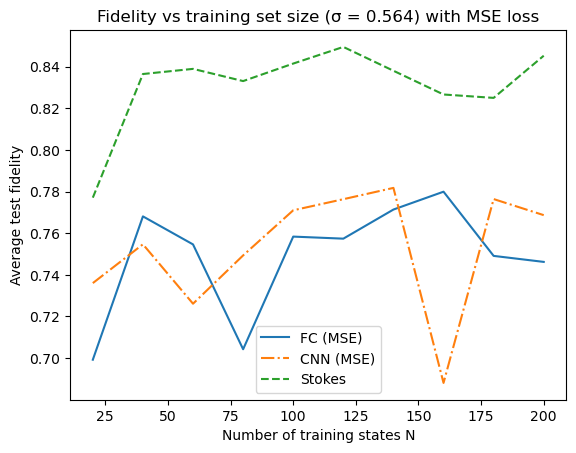

In [ ]:
plt.figure()
plt.plot(N_list, avg_fids_fc_mse,      label='FC (MSE)',  linestyle='-', color='turqoise')
plt.plot(N_list, avg_fids_cnn_mse,     label='CNN (MSE)', linestyle='-', color='cornflowerblue')
plt.plot(N_list, avg_fids_stokes_all,  label='Stokes',    linestyle='-', color='dimgrey')
plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"Fidelity vs training set size (σ = {sigma}) with MSE loss")
plt.legend()
plt.show()


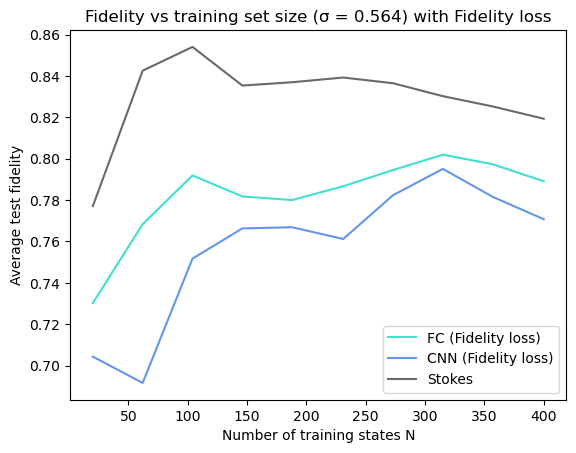

In [31]:
plt.figure()
plt.plot(N_list, avg_fids_fc_fid,      label='FC (Fidelity loss)',  linestyle='-', color='turquoise')
plt.plot(N_list, avg_fids_cnn_fid,     label='CNN (Fidelity loss)', linestyle='-', color='cornflowerblue')
plt.plot(N_list, avg_fids_stokes_all,  label='Stokes',              linestyle='-', color='dimgrey')
plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"Fidelity vs training set size (σ = {sigma}) with Fidelity loss")
plt.legend()
plt.show()


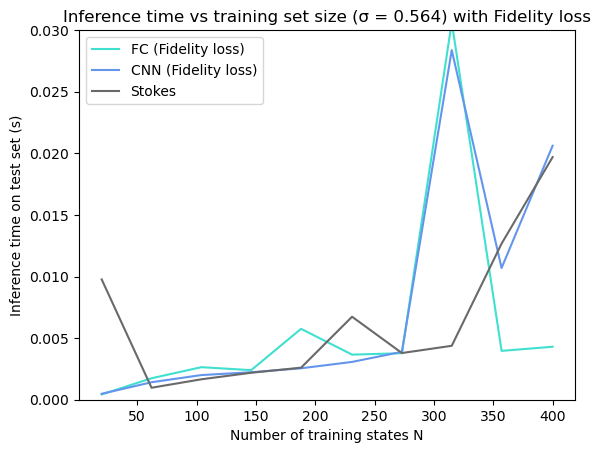

In [33]:
plt.figure()
plt.plot(N_list, times_fc_fid_test,      label='FC (Fidelity loss)',  linestyle='-', color='turquoise')
plt.plot(N_list, times_cnn_fid_test,     label='CNN (Fidelity loss)', linestyle='-', color='cornflowerblue')
plt.plot(N_list, times_stokes,            label='Stokes',    linestyle='-', color='dimgrey')
plt.xlabel("Number of training states N")
plt.ylabel("Inference time on test set (s)")
plt.ylim(0, 0.03)
plt.title(f"Inference time vs training set size (σ = {sigma}) with Fidelity loss")
plt.legend()
plt.show()

### Experimenting with changing parameters 

In [87]:
def run_model_curve(model_type: str,
                    loss_type: str,
                    lr: float,
                    n_epochs: int,
                    N_list=N_list,
                    P=P,
                    sigma=sigma,
                    seed=seed):
    """
    Run one model family (FC or CNN) with fixed hyperparameters over all N in N_list.
    Returns:
        avg_fids_model: np.array, shape (len(N_list),)
        avg_fids_stokes: np.array, same shape
    """
    avg_fids_model  = []
    avg_fids_stokes = []

    for N in N_list:
        print(f"\n[{model_type.upper()} | {loss_type}] N = {N}, lr={lr}, epochs={n_epochs}")

        np.random.seed(seed)
        torch.manual_seed(seed)

        X, Y = generate_dataset(N, P, sigma)
        split = int(0.8 * N)
        X_train, X_test = X[:split], X[split:]
        Y_train, Y_test = Y[:split], Y[split:]

        X_train_t = torch.from_numpy(X_train.astype(np.float32))
        Y_train_t = torch.from_numpy(Y_train.astype(np.float32))
        X_test_t  = torch.from_numpy(X_test.astype(np.float32))

        avg_fid_stokes, _ = precompute_stokes_fidelities(X_test, Y_test)
        avg_fids_stokes.append(avg_fid_stokes)

        torch.manual_seed(seed)
        if model_type.lower() == "fc":
            model = make_fc_model()
            is_cnn = False
        elif model_type.lower() == "cnn":
            model = make_cnn_model()
            is_cnn = True
        else:
            raise ValueError("model_type must be 'fc' or 'cnn'")

        model = train_model(model,
                            X_train_t, Y_train_t,
                            loss_type=loss_type,
                            n_epochs=n_epochs,
                            lr=lr,
                            is_cnn=is_cnn)

        avg_fid_model = evaluate_model_fidelity(model, X_test_t, Y_test, is_cnn=is_cnn)
        avg_fids_model.append(avg_fid_model)

        print(f"    Avg model fidelity:  {avg_fid_model:.6e}")
        print(f"    Avg Stokes fidelity: {avg_fid_stokes:.6e}")

    return np.array(avg_fids_model), np.array(avg_fids_stokes)

In [88]:
lrs = [1e-4, 3e-4, 1e-3]   # edit these as you like

fc_fid_lr_curves   = []
stokes_ref_fc_fid  = None

for lr in lrs:
    avg_model, avg_stokes = run_model_curve(
        model_type="fc",
        loss_type="fidelity",
        lr=lr,
        n_epochs=N_EPOCHS_FC
    )
    fc_fid_lr_curves.append(avg_model)

    # Use the first run's Stokes as reference (they should all be identical with same seed)
    if stokes_ref_fc_fid is None:
        stokes_ref_fc_fid = avg_stokes

# Plot
plt.figure()
for lr, curve in zip(lrs, fc_fid_lr_curves):
    plt.plot(N_list, curve, marker='o', label=f"FC (τ), lr = {lr:g}")

plt.plot(N_list, stokes_ref_fc_fid, linestyle='--', label='Stokes baseline')

plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title("FC (τ) with fidelity loss – learning rate sweep")
plt.legend()
# No gridlines
plt.tight_layout()
plt.savefig("plots/fc_tau_fid_lr_sweep.png", dpi=300)
plt.close()



[FC | fidelity] N = 20, lr=0.0001, epochs=400
    Avg model fidelity:  7.344708e-01
    Avg Stokes fidelity: 7.770460e-01

[FC | fidelity] N = 40, lr=0.0001, epochs=400
    Avg model fidelity:  7.848768e-01
    Avg Stokes fidelity: 8.364170e-01

[FC | fidelity] N = 60, lr=0.0001, epochs=400
    Avg model fidelity:  7.778202e-01
    Avg Stokes fidelity: 8.388879e-01

[FC | fidelity] N = 80, lr=0.0001, epochs=400
    Avg model fidelity:  7.767116e-01
    Avg Stokes fidelity: 8.330264e-01

[FC | fidelity] N = 100, lr=0.0001, epochs=400
    Avg model fidelity:  7.969590e-01
    Avg Stokes fidelity: 8.414333e-01

[FC | fidelity] N = 120, lr=0.0001, epochs=400
    Avg model fidelity:  7.838157e-01
    Avg Stokes fidelity: 8.494294e-01

[FC | fidelity] N = 140, lr=0.0001, epochs=400
    Avg model fidelity:  7.695396e-01
    Avg Stokes fidelity: 8.379878e-01

[FC | fidelity] N = 160, lr=0.0001, epochs=400
    Avg model fidelity:  7.935563e-01
    Avg Stokes fidelity: 8.265853e-01

[FC | fidel

In [89]:
epoch_list = [200, 400, 800]   # edit these as you like
lr_fc_fid  = 3e-4              # choose your "default" LR

fc_fid_epoch_curves  = []
stokes_ref_fc_epoch  = None

for n_epochs in epoch_list:
    avg_model, avg_stokes = run_model_curve(
        model_type="fc",
        loss_type="fidelity",
        lr=lr_fc_fid,
        n_epochs=n_epochs
    )
    fc_fid_epoch_curves.append(avg_model)

    if stokes_ref_fc_epoch is None:
        stokes_ref_fc_epoch = avg_stokes

plt.figure()
for ne, curve in zip(epoch_list, fc_fid_epoch_curves):
    plt.plot(N_list, curve, marker='o', label=f"FC (τ), epochs = {ne}")

plt.plot(N_list, stokes_ref_fc_epoch, linestyle='--', label='Stokes baseline')

plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"FC (τ) with fidelity loss – epoch sweep (lr = {lr_fc_fid:g})")
plt.legend()
# No gridlines
plt.tight_layout()
plt.savefig("plots/fc_tau_fid_epoch_sweep.png", dpi=300)
plt.close()



[FC | fidelity] N = 20, lr=0.0003, epochs=200
    Avg model fidelity:  6.901630e-01
    Avg Stokes fidelity: 7.770460e-01

[FC | fidelity] N = 40, lr=0.0003, epochs=200
    Avg model fidelity:  7.722640e-01
    Avg Stokes fidelity: 8.364170e-01

[FC | fidelity] N = 60, lr=0.0003, epochs=200
    Avg model fidelity:  7.755147e-01
    Avg Stokes fidelity: 8.388879e-01

[FC | fidelity] N = 80, lr=0.0003, epochs=200
    Avg model fidelity:  7.696991e-01
    Avg Stokes fidelity: 8.330264e-01

[FC | fidelity] N = 100, lr=0.0003, epochs=200
    Avg model fidelity:  7.940793e-01
    Avg Stokes fidelity: 8.414333e-01

[FC | fidelity] N = 120, lr=0.0003, epochs=200
    Avg model fidelity:  7.806242e-01
    Avg Stokes fidelity: 8.494294e-01

[FC | fidelity] N = 140, lr=0.0003, epochs=200
    Avg model fidelity:  7.744039e-01
    Avg Stokes fidelity: 8.379878e-01

[FC | fidelity] N = 160, lr=0.0003, epochs=200
    Avg model fidelity:  7.808636e-01
    Avg Stokes fidelity: 8.265853e-01

[FC | fidel

In [90]:
lrs_cnn = [1e-4, 3e-4, 1e-3]

cnn_fid_lr_curves   = []
stokes_ref_cnn_fid  = None

for lr in lrs_cnn:
    avg_model, avg_stokes = run_model_curve(
        model_type="cnn",
        loss_type="fidelity",
        lr=lr,
        n_epochs=N_EPOCHS_CNN
    )
    cnn_fid_lr_curves.append(avg_model)

    if stokes_ref_cnn_fid is None:
        stokes_ref_cnn_fid = avg_stokes

plt.figure()
for lr, curve in zip(lrs_cnn, cnn_fid_lr_curves):
    plt.plot(N_list, curve, marker='o', label=f"CNN (τ), lr = {lr:g}")

plt.plot(N_list, stokes_ref_cnn_fid, linestyle='--', label='Stokes baseline')

plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title("CNN (τ) with fidelity loss – learning rate sweep")
plt.legend()
# No gridlines
plt.tight_layout()
plt.savefig("plots/cnn_tau_fid_lr_sweep.png", dpi=300)
plt.close()


[CNN | fidelity] N = 20, lr=0.0001, epochs=400
    Avg model fidelity:  7.540417e-01
    Avg Stokes fidelity: 7.770460e-01

[CNN | fidelity] N = 40, lr=0.0001, epochs=400
    Avg model fidelity:  7.606949e-01
    Avg Stokes fidelity: 8.364170e-01

[CNN | fidelity] N = 60, lr=0.0001, epochs=400
    Avg model fidelity:  7.414812e-01
    Avg Stokes fidelity: 8.388879e-01

[CNN | fidelity] N = 80, lr=0.0001, epochs=400
    Avg model fidelity:  7.629284e-01
    Avg Stokes fidelity: 8.330264e-01

[CNN | fidelity] N = 100, lr=0.0001, epochs=400
    Avg model fidelity:  7.800713e-01
    Avg Stokes fidelity: 8.414333e-01

[CNN | fidelity] N = 120, lr=0.0001, epochs=400
    Avg model fidelity:  7.820782e-01
    Avg Stokes fidelity: 8.494294e-01

[CNN | fidelity] N = 140, lr=0.0001, epochs=400
    Avg model fidelity:  7.478460e-01
    Avg Stokes fidelity: 8.379878e-01

[CNN | fidelity] N = 160, lr=0.0001, epochs=400
    Avg model fidelity:  7.725071e-01
    Avg Stokes fidelity: 8.265853e-01

[CN

In [91]:
epoch_list_cnn = [600, 1200, 1800]
lr_cnn_mse     = 3e-4

cnn_mse_epoch_curves = []
stokes_ref_cnn_mse   = None

for n_epochs in epoch_list_cnn:
    avg_model, avg_stokes = run_model_curve(
        model_type="cnn",
        loss_type="mse",
        lr=lr_cnn_mse,
        n_epochs=n_epochs
    )
    cnn_mse_epoch_curves.append(avg_model)

    if stokes_ref_cnn_mse is None:
        stokes_ref_cnn_mse = avg_stokes

plt.figure()
for ne, curve in zip(epoch_list_cnn, cnn_mse_epoch_curves):
    plt.plot(N_list, curve, marker='o', label=f"CNN (τ), epochs = {ne}")

plt.plot(N_list, stokes_ref_cnn_mse, linestyle='--', label='Stokes baseline')

plt.xlabel("Number of training states N")
plt.ylabel("Average test fidelity")
plt.title(f"CNN (τ) with MSE-on-ρ – epoch sweep (lr = {lr_cnn_mse:g})")
plt.legend()
# No gridlines
plt.tight_layout()
plt.savefig("plots/cnn_tau_mse_epoch_sweep.png", dpi=300)
plt.close()



[CNN | mse] N = 20, lr=0.0003, epochs=600
    Avg model fidelity:  7.505142e-01
    Avg Stokes fidelity: 7.770460e-01

[CNN | mse] N = 40, lr=0.0003, epochs=600
    Avg model fidelity:  7.656495e-01
    Avg Stokes fidelity: 8.364170e-01

[CNN | mse] N = 60, lr=0.0003, epochs=600
    Avg model fidelity:  7.509926e-01
    Avg Stokes fidelity: 8.388879e-01

[CNN | mse] N = 80, lr=0.0003, epochs=600
    Avg model fidelity:  7.547352e-01
    Avg Stokes fidelity: 8.330264e-01

[CNN | mse] N = 100, lr=0.0003, epochs=600
    Avg model fidelity:  7.648533e-01
    Avg Stokes fidelity: 8.414333e-01

[CNN | mse] N = 120, lr=0.0003, epochs=600
    Avg model fidelity:  7.941467e-01
    Avg Stokes fidelity: 8.494294e-01

[CNN | mse] N = 140, lr=0.0003, epochs=600
    Avg model fidelity:  7.814789e-01
    Avg Stokes fidelity: 8.379878e-01

[CNN | mse] N = 160, lr=0.0003, epochs=600
    Avg model fidelity:  8.006313e-01
    Avg Stokes fidelity: 8.265853e-01

[CNN | mse] N = 180, lr=0.0003, epochs=600
